In [1]:
# Enable inline plotting for Jupyter notebooks
%matplotlib inline

# Import required libraries for visualization
import warnings
warnings.filterwarnings('ignore')

print("Notebook configured for interactive visualization")

Notebook configured for interactive visualization


## NIfTI Image Information Extractor

Function to load NIfTI files and extract comprehensive metadata including dimensions, resolution, orientation, and intensity statistics.

In [3]:
import nibabel as nib
import numpy as np
from pathlib import Path

def load_nifti_with_info(file_path):
    """
    Load a NIfTI MRI image and extract comprehensive information.
    
    Args:
        file_path: Path to the NIfTI file (.nii or .nii.gz)
    
    Returns:
        tuple: (data_array, info_dict)
            - data_array: 3D/4D numpy array with image data
            - info_dict: Dictionary containing all metadata
    """
    try:
        # Load the NIfTI file
        img = nib.load(str(file_path))
        
        # Get the image data
        data = img.get_fdata()
        
        # Get header information
        header = img.header
        
        # Compile comprehensive information
        info = {
            # File information
            'file_path': str(file_path),
            'file_name': Path(file_path).name,
            'file_size_mb': Path(file_path).stat().st_size / (1024 * 1024),
            
            # Shape and dimensions
            'shape': data.shape,
            'ndim': data.ndim,
            'width': data.shape[0],
            'height': data.shape[1],
            'depth': data.shape[2] if data.ndim >= 3 else None,
            'time_points': data.shape[3] if data.ndim >= 4 else None,
            
            # Voxel/Resolution information
            'voxel_size': tuple(header.get_zooms()),
            'voxel_size_x_mm': header.get_zooms()[0],
            'voxel_size_y_mm': header.get_zooms()[1],
            'voxel_size_z_mm': header.get_zooms()[2] if len(header.get_zooms()) >= 3 else None,
            'voxel_volume_mm3': np.prod(header.get_zooms()[:3]) if len(header.get_zooms()) >= 3 else None,
            
            # Physical size
            'physical_size_x_mm': data.shape[0] * header.get_zooms()[0],
            'physical_size_y_mm': data.shape[1] * header.get_zooms()[1],
            'physical_size_z_mm': data.shape[2] * header.get_zooms()[2] if data.ndim >= 3 and len(header.get_zooms()) >= 3 else None,
            
            # Intensity statistics
            'data_type': str(data.dtype),
            'min_intensity': float(np.min(data)),
            'max_intensity': float(np.max(data)),
            'mean_intensity': float(np.mean(data)),
            'std_intensity': float(np.std(data)),
            'median_intensity': float(np.median(data)),
            
            # Non-zero voxel statistics (useful for brain images)
            'num_nonzero_voxels': int(np.count_nonzero(data)),
            'num_total_voxels': int(data.size),
            'percent_nonzero': float(100 * np.count_nonzero(data) / data.size),
            
            # Orientation information
            'affine': img.affine.tolist(),
            'orientation': nib.aff2axcodes(img.affine),
            
            # Header metadata
            'qform_code': int(header['qform_code']),
            'sform_code': int(header['sform_code']),
            'units': str(header.get_xyzt_units()),
            
            # Description from header
            'description': header.get('descrip', b'').decode('utf-8', errors='ignore').strip(),
        }
        
        return data, info
        
    except Exception as e:
        print(f"❌ Error loading file: {e}")
        return None, {'error': str(e), 'file_path': str(file_path)}


def print_nifti_info(info, verbose=True):
    """
    Print NIfTI image information in a readable format.
    
    Args:
        info: Dictionary returned by load_nifti_with_info()
        verbose: If True, print all details. If False, print summary only.
    """
    if 'error' in info:
        print(f"❌ Error: {info['error']}")
        return
    
    print(f"\n{'='*80}")
    print(f"📊 NIfTI Image Information")
    print(f"{'='*80}")
    
    # File information
    print(f"\n📁 File: {info['file_name']}")
    print(f"   Size: {info['file_size_mb']:.2f} MB")
    
    # Dimensions
    print(f"\n📐 Dimensions:")
    print(f"   Shape: {info['shape']}")
    print(f"   Width (X):  {info['width']} voxels")
    print(f"   Height (Y): {info['height']} voxels")
    if info['depth']:
        print(f"   Depth (Z):  {info['depth']} slices")
    if info['time_points']:
        print(f"   Time:       {info['time_points']} volumes")
    
    # Resolution
    print(f"\n🔬 Resolution:")
    print(f"   Voxel size: {info['voxel_size_x_mm']:.4f} × {info['voxel_size_y_mm']:.4f} × {info['voxel_size_z_mm']:.4f} mm")
    if info['voxel_volume_mm3']:
        print(f"   Voxel volume: {info['voxel_volume_mm3']:.6f} mm³")
    print(f"   Physical size: {info['physical_size_x_mm']:.2f} × {info['physical_size_y_mm']:.2f} × {info['physical_size_z_mm']:.2f} mm")
    
    # Intensity statistics
    print(f"\n💡 Intensity Statistics:")
    print(f"   Data type: {info['data_type']}")
    print(f"   Range:     [{info['min_intensity']:.2f}, {info['max_intensity']:.2f}]")
    print(f"   Mean:      {info['mean_intensity']:.2f}")
    print(f"   Std Dev:   {info['std_intensity']:.2f}")
    print(f"   Median:    {info['median_intensity']:.2f}")
    
    # Non-zero voxels
    print(f"\n🧠 Voxel Statistics:")
    print(f"   Total voxels:    {info['num_total_voxels']:,}")
    print(f"   Non-zero voxels: {info['num_nonzero_voxels']:,} ({info['percent_nonzero']:.1f}%)")
    
    # Orientation
    print(f"\n🧭 Orientation: {info['orientation']}")
    
    if verbose and info['description']:
        print(f"\n📝 Description: {info['description']}")
    
    print(f"\n{'='*80}\n")


# Example usage function
def compare_two_nifti_files(file_path1, file_path2):
    """
    Load and compare two NIfTI files side by side.
    
    Args:
        file_path1: Path to first NIfTI file
        file_path2: Path to second NIfTI file
    """
    print(f"\n{'='*80}")
    print(f"🔍 Comparing Two NIfTI Images")
    print(f"{'='*80}\n")
    
    data1, info1 = load_nifti_with_info(file_path1)
    data2, info2 = load_nifti_with_info(file_path2)
    
    if data1 is None or data2 is None:
        print("❌ Error loading one or both files")
        return
    
    print(f"📁 File 1: {info1['file_name']}")
    print(f"📁 File 2: {info2['file_name']}\n")
    
    comparisons = [
        ('Shape', 'shape'),
        ('Voxel size (mm)', 'voxel_size'),
        ('Data type', 'data_type'),
        ('Orientation', 'orientation'),
        ('File size (MB)', 'file_size_mb'),
        ('Intensity range', lambda x: f"[{x['min_intensity']:.2f}, {x['max_intensity']:.2f}]"),
        ('Mean intensity', 'mean_intensity'),
    ]
    
    for label, key in comparisons:
        if callable(key):
            val1 = key(info1)
            val2 = key(info2)
        else:
            val1 = info1[key]
            val2 = info2[key]
        
        match = "✅" if val1 == val2 else "❌"
        print(f"{match} {label}:")
        print(f"   File 1: {val1}")
        print(f"   File 2: {val2}")
        print()
    
    print(f"{'='*80}\n")
    
    return data1, data2, info1, info2

print("✅ NIfTI dataloader functions created successfully!")
print("   - load_nifti_with_info(file_path)")
print("   - print_nifti_info(info, verbose=True)")
print("   - compare_two_nifti_files(file_path1, file_path2)")

✅ NIfTI dataloader functions created successfully!
   - load_nifti_with_info(file_path)
   - print_nifti_info(info, verbose=True)
   - compare_two_nifti_files(file_path1, file_path2)


In [ ]:
conda install -c conda-forge jupyterlab_widgets notebook

Channels:
 - conda-forge
 - defaults
Platform: linux-64
Solving environment: done
Solving environment- done
done

# All requested packages already installed.


# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.

Note: you may need to restart the kernel to use updated packages.


In [8]:
!pip install matplotlib numpy SimpleITK opencv-python


  Using cached numpy-2.0.2-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (19.5 MB)
  Using cached numpy-2.0.2-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (19.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.12.0 requires numpy<1.24,>=1.22, but you have numpy 2.0.2 which is incompatible.
scipy 1.10.1 requires numpy<1.27.0,>=1.19.5, but you have numpy 2.0.2 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the follo

In [9]:
# Install required packages
!pip install antspyx SimpleITK matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 2.1 MB/s eta 0:00:0000:0100:01━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/22.4 MB ? eta -:--:--
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 2.1 MB/s eta 0:00:0000:01
  Using cached numpy-1.26.4-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.2 MB)
  Using cached numpy-1.26.4-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.2 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.12.0 requires numpy<1.24,>=1.22, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.1

In [10]:
!pip install torchio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/194.0 kB ? eta -:--:--  Downloading torchio-0.20.23-py3-none-any.whl (194 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.0/194.0 kB 858.4 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.0/194.0 kB 858.4 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━ 30.7/47.0 kB 38.1 MB/s eta 0:00:01  Downloading typer-0.20.0-py3-none-any.whl (47 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.0/47.0 kB 591.8 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.0/47.0 kB 591.8 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/243.4 kB ? eta -:--:--  Downloading rich-14.2.0-py3-none-any.whl (243 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.4/243.4 kB 3.5 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.4/243.4 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/128.9 kB ? eta -:--:--  Downloading humanize

In [ ]:
conda install -c conda-forge opencv

Channels:
 - conda-forge
 - defaults
Platform: linux-64
Solving environment: done
Solving environment: done
done

## Package Plan ##

  environment location: /mnt/code/AKIB/ulf

  added / updated specs:
    - opencv


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    imath-3.2.2                |       hde8ca8f_0         157 KB  conda-forge
    libopencv-4.12.0           |qt6_py310hdb0ca46_607        31.1 MB  conda-forge
    opencv-4.12.0              |qt6_py310hec850f8_607          27 KB  conda-forge
    openexr-3.4.2              |       hff891e4_0         1.3 MB  conda-forge
    py-opencv-4.12.0           |qt6_py310h89973df_607         1.1 MB  conda-forge
    ------------------------------------------------------------
                                           Total:        33.7 MB

The following packages will be UPDATED:

  imath                                    3.2.1-hde8ca8f_0 --> 

In [ ]:
conda install -c conda-forge ipywidgets=7.7.1


Channels:
 - conda-forge
 - defaults
Platform: linux-64
Solving environment: done
Solving environment: done
done

# All requested packages already installed.


# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.

Note: you may need to restart the kernel to use updated packages.


Helper functions

In [20]:
import matplotlib.pyplot as plt
from ipywidgets import interact, interactive, fixed, widgets
from IPython.display import display, clear_output
import numpy as np
import SimpleITK as sitk
import cv2

def explore_3D_array(arr: np.ndarray, cmap: str = 'gray'):
  """
  Given a 3D array with shape (Z,X,Y) This function will create an interactive
  widget to check out all the 2D arrays with shape (X,Y) inside the 3D array. 
  The purpose of this function to visual inspect the 2D arrays in the image. 

  Args:
    arr : 3D array with shape (Z,X,Y) that represents the volume of a MRI image
    cmap : Which color map use to plot the slices in matplotlib.pyplot
  """
  # Create the output widget
  output = widgets.Output()
  
  def view_slice(SLICE):
    with output:
      clear_output(wait=True)
      plt.figure(figsize=(7,7))
      plt.imshow(arr[SLICE, :, :], cmap=cmap)
      plt.title(f'Slice {SLICE}')
      plt.colorbar()
      plt.tight_layout()
  
  # Create the widget
  slider = widgets.IntSlider(min=0, max=arr.shape[0]-1, step=1, description='Slice:')
  
  # Link the widget to the function
  ui = interactive(view_slice, SLICE=slider)
  
  # Display the widget and output area
  display(ui, output)
  
  # Show initial slice
  view_slice(0)


def explore_3D_array_comparison(arr_before: np.ndarray, arr_after: np.ndarray, cmap: str = 'gray'):
  """
  Given two 3D arrays with shape (Z,X,Y) This function will create an interactive
  widget to check out all the 2D arrays with shape (X,Y) inside the 3D arrays.
  The purpose of this function to visual compare the 2D arrays after some transformation. 

  Args:
    arr_before : 3D array with shape (Z,X,Y) that represents the volume of a MRI image, before any transform
    arr_after : 3D array with shape (Z,X,Y) that represents the volume of a MRI image, after some transform    
    cmap : Which color map use to plot the slices in matplotlib.pyplot
  """
  assert arr_after.shape == arr_before.shape
  
  # Create the output widget
  output = widgets.Output()
  
  def view_comparison(SLICE):
    with output:
      clear_output(wait=True)
      fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
      
      # Left image (Before)
      ax1.imshow(arr_before[SLICE, :, :], cmap=cmap)
      ax1.axis('on')
      
      # Right image (After)
      ax2.imshow(arr_after[SLICE, :, :], cmap=cmap)
      ax2.axis('on')
      
      plt.tight_layout()
      plt.show()
  
  # Create the widget
  slider = widgets.IntSlider(min=0, max=arr_before.shape[0]-1, step=1, description='Slice:')
  
  # Link the widget to the function
  ui = interactive(view_comparison, SLICE=slider)
  
  # Display the widget and output area
  display(ui, output)
  
  # Show initial slice
  view_comparison(0)


def show_sitk_img_info(img: sitk.Image):
  """
  Given a sitk.Image instance prints the information about the MRI image contained.

  Args:
    img : instance of the sitk.Image to check out
  """
  pixel_type = img.GetPixelIDTypeAsString()
  origin = img.GetOrigin()
  dimensions = img.GetSize()
  spacing = img.GetSpacing()
  direction = img.GetDirection()

  info = {'Pixel Type' : pixel_type, 'Dimensions': dimensions, 'Spacing': spacing, 'Origin': origin,  'Direction' : direction}
  for k,v in info.items():
    print(f' {k} : {v}')


def add_suffix_to_filename(filename: str, suffix:str) -> str:
  """
  Takes a NIfTI filename and appends a suffix.

  Args:
      filename : NIfTI filename
      suffix : suffix to append

  Returns:
      str : filename after append the suffix
  """
  if filename.endswith('.nii'):
      result = filename.replace('.nii', f'_{suffix}.nii')
      return result
  elif filename.endswith('.nii.gz'):
      result = filename.replace('.nii.gz', f'_{suffix}.nii.gz')
      return result
  else:
      raise RuntimeError('filename with unknown extension')


def rescale_linear(array: np.ndarray, new_min: int, new_max: int):
  """Rescale an array linearly."""
  minimum, maximum = np.min(array), np.max(array)
  m = (new_max - new_min) / (maximum - minimum)
  b = new_min - m * minimum
  return m * array + b


def explore_3D_array_with_mask_contour(arr: np.ndarray, mask: np.ndarray, thickness: int = 1):
  """
  Given a 3D array with shape (Z,X,Y) This function will create an interactive
  widget to check out all the 2D arrays with shape (X,Y) inside the 3D array. The binary
  mask provided will be used to overlay contours of the region of interest over the 
  array. The purpose of this function is to visual inspect the region delimited by the mask.

  Args:
    arr : 3D array with shape (Z,X,Y) that represents the volume of a MRI image
    mask : binary mask to obtain the region of interest
  """
  assert arr.shape == mask.shape
  
  _arr = rescale_linear(arr,0,1)
  _mask = rescale_linear(mask,0,1)
  _mask = _mask.astype(np.uint8)
  
  # Create the output widget
  output = widgets.Output()
  
  def view_contour(SLICE):
    with output:
      clear_output(wait=True)
      plt.figure(figsize=(7,7))
      
      arr_rgb = cv2.cvtColor(_arr[SLICE, :, :], cv2.COLOR_GRAY2RGB)
      contours, _ = cv2.findContours(_mask[SLICE, :, :], cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
      
      arr_with_contours = cv2.drawContours(arr_rgb, contours, -1, (0,1,0), thickness)

      plt.imshow(arr_with_contours)
      plt.title(f'Slice {SLICE} with contours')
      plt.tight_layout()
      plt.show()
  
  # Create the widget
  slider = widgets.IntSlider(min=0, max=arr.shape[0]-1, step=1, description='Slice:')
  
  # Link the widget to the function
  ui = interactive(view_contour, SLICE=slider)
  
  # Display the widget and output area
  display(ui, output)
  
  # Show initial slice
  view_contour(0)

Data Loader


In [12]:
import os
import glob
import nibabel as nib
import numpy as np

# --- Configuration ---
BASE_DIR = '/mnt/Data/AKIB/Training data'
TARGET_SEQUENCE = 'T1' # Focusing on T1 for a start, as it is standard. You can loop through all three later.
NUM_SUBJECTS = 50

def load_image(filepath):
    """Loads a NIfTI file and returns the data array and NIfTI object."""
    try:
        img = nib.load(filepath)
        # Using .get_fdata() to get the image data as a floating-point array
        data = img.get_fdata()
        return data, img
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None, None

def organize_data_paths(base_dir, num_subjects, sequence):
    """Generates a list of dictionaries with paired file paths for all subjects."""
    data_list = []
    
    # Subject folders are named 1, 2, 3, ...
    for sub_id in range(1, num_subjects + 1):
        subject_dir = os.path.join(base_dir, str(sub_id))
        
        # Build file paths
        ulf_path = os.path.join(subject_dir, '64mT', f'{sub_id}_{sequence}.nii.gz')
        hf_path = os.path.join(subject_dir, '3T', f'{sub_id}_{sequence}.nii.gz')
        
        # Check if files exist before adding to the list
        if os.path.exists(ulf_path) and os.path.exists(hf_path):
            data_list.append({
                'subject_id': sub_id,
                'ulf_path': ulf_path,
                'hf_path': hf_path
            })
        else:
            print(f"Warning: Missing files for Subject {sub_id} ({sequence}). Skipping.")
            
    return data_list

# Get the list of file pairs
data_pairs = organize_data_paths(BASE_DIR, NUM_SUBJECTS, TARGET_SEQUENCE)
print(f"Found {len(data_pairs)} valid T1-weighted subject pairs.")
data_pairs[0]['ulf_path']

Found 50 valid T1-weighted subject pairs.


'/mnt/Data/AKIB/Training data/1/64mT/1_T1.nii.gz'

In [13]:
import os
from helpers import *

import ants
import SimpleITK as sitk

print(f'AntsPy version = {ants.__version__}')
print(f'SimpleITK version = {sitk.__version__}')

AntsPy version = 0.6.1
SimpleITK version = 2.5.2


In [14]:
# Visualize the original 3D images before registration and preprocessing
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt

# Get the sample pair that we'll process
sample_pair = data_pairs[0]
print(f"Visualizing Subject {sample_pair['subject_id']} before registration...")

# Load the original images
ulf_sitk_orig = sitk.ReadImage(sample_pair['ulf_path'], sitk.sitkFloat32)
hf_sitk_orig = sitk.ReadImage(sample_pair['hf_path'], sitk.sitkFloat32)

# Convert to numpy arrays for visualization
ulf_orig = sitk.GetArrayFromImage(ulf_sitk_orig)
hf_orig = sitk.GetArrayFromImage(hf_sitk_orig)

print(f"Original ULF shape: {ulf_orig.shape}")
print(f"Original HF shape: {hf_orig.shape}")
print(f"ULF spacing: {ulf_sitk_orig.GetSpacing()}")
print(f"HF spacing: {hf_sitk_orig.GetSpacing()}")

# Visualize using the interactive slider function
print("\nInteractive visualization of ULF and HF images (before registration):")
# Show the ULF and HF images side by side with slider
if ulf_orig.shape[0] == hf_orig.shape[0]:
    explore_3D_array_comparison(ulf_orig, hf_orig, cmap='gray')
else:
    print("\nULF and HF have different numbers of slices, cannot directly compare side by side.")
    print(f"ULF has {ulf_orig.shape[0]} slices, HF has {hf_orig.shape[0]} slices.")

Visualizing Subject 1 before registration...
Original ULF shape: (160, 224, 224)
Original HF shape: (160, 224, 224)
ULF spacing: (1.0, 1.0, 1.0)
HF spacing: (1.0, 1.0, 1.0)

Interactive visualization of ULF and HF images (before registration):


interactive(children=(IntSlider(value=79, description='SLICE', max=159), Output()), _dom_classes=('widget-inte…

Image registration

In [ ]:
import SimpleITK as sitk

def preprocess_volumes(ulf_path, hf_path, target_spacing=(1.0, 1.0, 1.0)):
    # Load with SimpleITK
    ulf_sitk = sitk.ReadImage(ulf_path, sitk.sitkFloat32)
    hf_sitk = sitk.ReadImage(hf_path, sitk.sitkFloat32)

    # --- 1. Registration (Aligning ULF to HF) ---
    # Use a simple rigid registration to fine-tune alignment
    R = sitk.ImageRegistrationMethod()
    R.SetMetricAsMattesMutualInformation(numberOfHistogramBins=50)
    R.SetOptimizerAsRegularStepGradientDescent(learningRate=2.0, numberOfIterations=100, minStep=0.01)
    R.SetInterpolator(sitk.sitkLinear)
    
    # Use the HF image as the fixed image and the ULF image as the moving image
    #### Place moving image to fixed image space
    
    initial_transform = sitk.CenteredTransformInitializer(
        hf_sitk, ulf_sitk, sitk.Euler3DTransform(), sitk.CenteredTransformInitializerFilter.GEOMETRY
    )
    
    # Set the initial transform before executing
    R.SetInitialTransform(initial_transform)
    
    # Execute registration with just the fixed and moving images
    final_transform = R.Execute(hf_sitk, ulf_sitk)
    
    # Apply the final transform to the ULF image
    resampled_ulf = sitk.Resample(
        ulf_sitk, hf_sitk, final_transform, sitk.sitkBSpline, 0.0, ulf_sitk.GetPixelID()
    )
    
    # --- 2. Resampling (Setting Isotropic Resolution) ---
    # Define a common reference space for isotropic 1mm resolution
    
    # Calculate new size to maintain physical size when changing spacing
    new_size = [int(sz * orig_sp / target_sp) for sz, orig_sp, target_sp in 
               zip(hf_sitk.GetSize(), hf_sitk.GetSpacing(), target_spacing)]
    
    # Create a reference image with the desired spacing
    reference_image = sitk.Image(new_size, hf_sitk.GetPixelID())
    reference_image.SetOrigin(hf_sitk.GetOrigin())
    reference_image.SetSpacing(target_spacing)
    reference_image.SetDirection(hf_sitk.GetDirection())
    
    # Resample both images to the new isotropic reference space
    resampled_hf = sitk.Resample(hf_sitk, reference_image)
    resampled_ulf = sitk.Resample(resampled_ulf, reference_image) # Use the aligned ULF

    # Convert back to numpy array for deep learning
    ulf_data_out = sitk.GetArrayFromImage(resampled_ulf)
    hf_data_out = sitk.GetArrayFromImage(resampled_hf)
    
    return ulf_data_out, hf_data_out

# --- Example Usage (Process one subject) ---
sample_pair = data_pairs[0]
print(f"\nProcessing Subject {sample_pair['subject_id']}...")

ulf_processed, hf_processed = preprocess_volumes(sample_pair['ulf_path'], sample_pair['hf_path'])
print(f"Processed ULF shape: {ulf_processed.shape}")
print(f"Processed HF shape: {hf_processed.shape}")

# Now, loop through all data pairs, save the processed NumPy files, 
# and move on to normalization and patching (next steps).


Processing Subject 1...
Processed ULF shape: (160, 224, 224)
Processed HF shape: (160, 224, 224)
Processed ULF shape: (160, 224, 224)
Processed HF shape: (160, 224, 224)


In [ ]:
# Visualize the processed and registered images
print("Visualizing the processed images after registration")
print("ULF shape:", ulf_processed.shape)
print("HF shape:", hf_processed.shape)

ulf_unprocessed = sitk.GetArrayFromImage(sitk.ReadImage(sample_pair['ulf_path'], sitk.sitkFloat32))
hf_unprocessed = sitk.GetArrayFromImage(sitk.ReadImage(sample_pair['hf_path'], sitk.sitkFloat32))

# Use our comparison function to view both images side by side
explore_3D_array_comparison(ulf_unprocessed, ulf_processed, cmap='gray')
print("Interactive visualization launched. Use the slider to browse through slices.")

Visualizing the processed images after registration
ULF shape: (160, 224, 224)
HF shape: (160, 224, 224)


interactive(children=(IntSlider(value=79, description='SLICE', max=159), Output()), _dom_classes=('widget-inte…

Interactive visualization launched. Use the slider to browse through slices.


In [ ]:
# Use our comparison function to view both images side by side
explore_3D_array_comparison(hf_unprocessed, hf_processed, cmap='gray')
print("Interactive visualization launched. Use the slider to browse through slices.")

interactive(children=(IntSlider(value=79, description='SLICE', max=159), Output()), _dom_classes=('widget-inte…

Interactive visualization launched. Use the slider to browse through slices.


In [ ]:
# Process and save multiple subjects
import os

def process_and_save_all_subjects(data_pairs, output_dir='/mnt/Data/AKIB/processed_data', max_subjects=50):
    """
    Process multiple subjects and save the registered and resampled data
    
    Args:
        data_pairs: List of dictionaries containing file paths for each subject
        output_dir: Directory to save processed data
        max_subjects: Maximum number of subjects to process (for testing)
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Process each subject
    for i, subject_data in enumerate(data_pairs[:max_subjects]):
        subject_id = subject_data['subject_id']
        print(f"Processing subject {subject_id} ({i+1}/{min(len(data_pairs), max_subjects)})...")
        
        try:
            # Process the volumes
            ulf_processed, hf_processed = preprocess_volumes(
                subject_data['ulf_path'], 
                subject_data['hf_path']
            )
            
            # Save as numpy arrays
            subject_dir = os.path.join(output_dir, f"subject_{subject_id}")
            os.makedirs(subject_dir, exist_ok=True)
            
            np.save(os.path.join(subject_dir, 'ulf_processed.npy'), ulf_processed)
            np.save(os.path.join(subject_dir, 'hf_processed.npy'), hf_processed)
            
            print(f"Subject {subject_id} processed and saved successfully!")
            
        except Exception as e:
            print(f"Error processing subject {subject_id}: {str(e)}")
    
    print("Processing complete!")

process_and_save_all_subjects(data_pairs, max_subjects=50)

Processing subject 1 (1/50)...
Subject 1 processed and saved successfully!
Processing subject 2 (2/50)...
Subject 1 processed and saved successfully!
Processing subject 2 (2/50)...
Subject 2 processed and saved successfully!
Processing subject 3 (3/50)...
Subject 2 processed and saved successfully!
Processing subject 3 (3/50)...
Subject 3 processed and saved successfully!
Processing subject 4 (4/50)...
Subject 3 processed and saved successfully!
Processing subject 4 (4/50)...
Subject 4 processed and saved successfully!
Processing subject 5 (5/50)...
Subject 4 processed and saved successfully!
Processing subject 5 (5/50)...
Subject 5 processed and saved successfully!
Processing subject 6 (6/50)...
Subject 5 processed and saved successfully!
Processing subject 6 (6/50)...
Subject 6 processed and saved successfully!
Processing subject 7 (7/50)...
Subject 6 processed and saved successfully!
Processing subject 7 (7/50)...
Subject 7 processed and saved successfully!
Processing subject 8 (8/5

Percentile (0,1) or z_score NORMALIZATION


In [ ]:
# Data normalization and preparation for deep learning

def normalize_volume(volume, method='min_max'):
    """
    Normalize a 3D volume for neural network training
    
    Args:
        volume: 3D numpy array
        method: Normalization method ('min_max', 'z_score', or 'percentile')
        
    Returns:
        Normalized volume
    """
    if method == 'min_max':
        # Min-max scaling to [0,1]
        min_val = volume.min()
        max_val = volume.max()
        if max_val > min_val:
            return (volume - min_val) / (max_val - min_val)
        return volume - min_val  # Handle constant volumes
        
    elif method == 'z_score':
        # Z-score normalization (mean=0, std=1)
        mean_val = volume.mean()
        std_val = volume.std()
        if std_val > 0:
            return (volume - mean_val) / std_val
        return volume - mean_val  # Handle constant volumes
        
    elif method == 'percentile':
        # Percentile-based normalization (robust to outliers)
        p1 = np.percentile(volume, 1)
        p99 = np.percentile(volume, 99)
        if p99 > p1:
            vol_norm = (volume - p1) / (p99 - p1)
            # Clip values outside the percentile range
            return np.clip(vol_norm, 0, 1)
        return (volume - p1)  # Handle constant volumes
        
    else:
        raise ValueError(f"Unknown normalization method: {method}")

# Example usage
if 'ulf_processed' in locals() and 'hf_processed' in locals():
    # Normalize the processed volumes
    ulf_normalized = normalize_volume(ulf_processed, method='z_score')
    hf_normalized = normalize_volume(hf_processed, method='z_score')

    print("Normalization complete!")
    print(f"ULF normalized range: [{ulf_normalized.min():.4f}, {ulf_normalized.max():.4f}]")
    print(f"HF normalized range: [{hf_normalized.min():.4f}, {hf_normalized.max():.4f}]")
    
explore_3D_array_comparison(ulf_unprocessed, ulf_normalized, cmap='gray')
explore_3D_array_comparison(hf_unprocessed, hf_normalized, cmap='gray')

Normalization complete!
ULF normalized range: [-1.4882, 3.8893]
HF normalized range: [-0.7626, 3.8701]


interactive(children=(IntSlider(value=79, description='SLICE', max=159), Output()), _dom_classes=('widget-inte…

interactive(children=(IntSlider(value=79, description='SLICE', max=159), Output()), _dom_classes=('widget-inte…

In [54]:
# Load two NIfTI files (image + brain-extraction mask) and compare them
import os
import SimpleITK as sitk
import numpy as np

ulf_path = '/mnt/Data/AKIB/Training data/1/64mT/1_T2.nii.gz'
mask_path = '/mnt/Data/AKIB/Training data/1/64mT/1_T2_bet_mask.nii.gz'

print('ULF path:', ulf_path)
print('Mask path:', mask_path)

# Check files exist
if not os.path.exists(ulf_path):
    print(f"ERROR: ULF file not found: {ulf_path}")
else:
    print('ULF file found')

if not os.path.exists(mask_path):
    print(f"ERROR: Mask file not found: {mask_path}")
else:
    print('Mask file found')

# Read images
if os.path.exists(ulf_path) and os.path.exists(mask_path):
    ulf_img = sitk.ReadImage(ulf_path, sitk.sitkFloat32)
    mask_img = sitk.ReadImage(mask_path, sitk.sitkFloat32)

    ulf_arr = sitk.GetArrayFromImage(ulf_img)
    mask_arr = sitk.GetArrayFromImage(mask_img)

    print(f'ULF array shape: {ulf_arr.shape}, dtype: {ulf_arr.dtype}')
    print(f'Mask array shape: {mask_arr.shape}, dtype: {mask_arr.dtype}')

    # If shapes differ, warn (you can resample if needed)
    if ulf_arr.shape != mask_arr.shape:
        print('WARNING: Image and mask shapes differ. The comparison function expects identical shapes.')
        print('You may want to resample one image to the other''s grid before visualization.')
    else:
        # Use the comparison function defined earlier in the notebook
        print('\nLaunching interactive comparison (image vs mask)...')
        # The comparison function will show the image and the mask side-by-side
        explore_3D_array_comparison(ulf_arr, mask_arr, cmap='gray')
else:
    print('One or both files are missing; cannot run comparison.')


ULF path: /mnt/Data/AKIB/Training data/1/64mT/1_T2.nii.gz
Mask path: /mnt/Data/AKIB/Training data/1/64mT/1_T2_bet_mask.nii.gz
ULF file found
Mask file found
ULF array shape: (160, 224, 224), dtype: float32
Mask array shape: (160, 224, 224), dtype: float32

Launching interactive comparison (image vs mask)...


NameError: name 'explore_3D_array_comparison' is not defined

FLAIR: /mnt/Data/AKIB/Training data/1/3T/1_FLAIR.nii.gz
Mask : /mnt/Data/AKIB/Training data/1/3T/1_FLAIR_bet_mask.nii.gz
Out  : /mnt/Data/AKIB/Training data/1/3T/1_FLAIR_skullstripped.nii.gz
FLAIR pixel type: 8-bit unsigned integer
Mask pixel type : 8-bit unsigned integer
FLAIR size: (224, 224, 160)
Mask size : (224, 224, 160)
Saved skull-stripped image to /mnt/Data/AKIB/Training data/1/3T/1_FLAIR_skullstripped.nii.gz
Skull-stripped array shape: (160, 224, 224) dtype: uint8

Previewing middle slice (array index): 80


interactive(children=(IntSlider(value=0, description='Slice:', max=159), Output()), _dom_classes=('widget-inte…

Output()

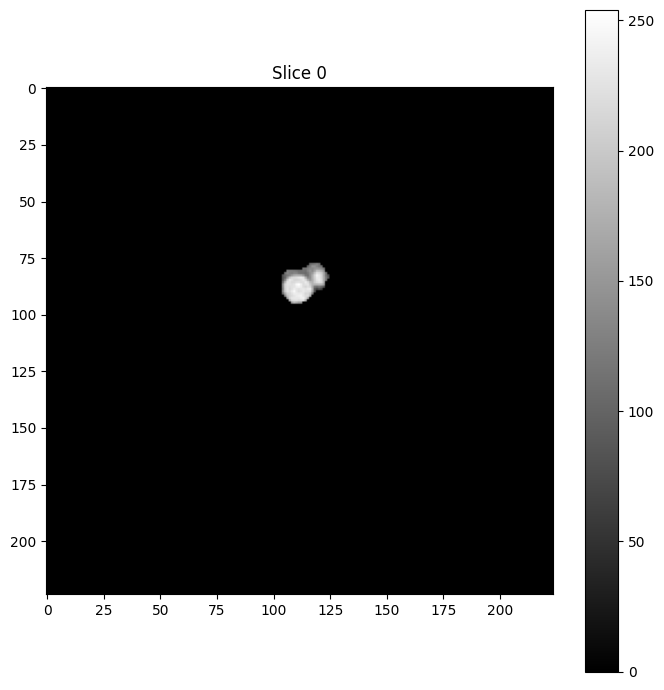

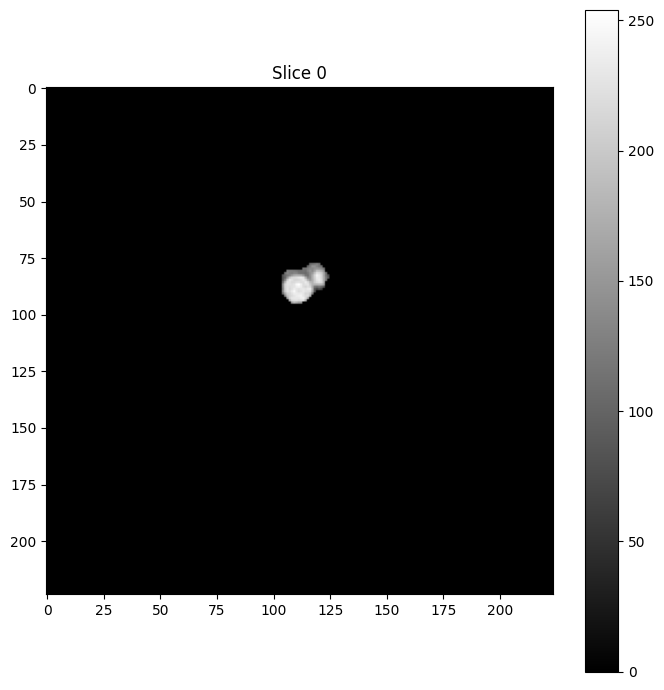

In [ ]:
# Apply BET mask to create a skull-stripped image (FLAIR example)
import os
import SimpleITK as sitk
import numpy as np

# Paths (FLAIR + brain extraction mask)
flair_path = '/mnt/Data/AKIB/Training data/1/3T/1_FLAIR.nii.gz'
mask_path = '/mnt/Data/AKIB/Training data/1/3T/1_FLAIR_bet_mask.nii.gz'

# Output path (uses helper add_suffix_to_filename() from earlier cells)
try:
    out_path = add_suffix_to_filename(flair_path, 'skullstripped')
except Exception:
    # fallback if helper not loaded
    out_path = flair_path.replace('.nii.gz', '_skullstripped.nii.gz') if flair_path.endswith('.nii.gz') else flair_path.replace('.nii', '_skullstripped.nii')

print('FLAIR:', flair_path)
print('Mask :', mask_path)
print('Out  :', out_path)

if not os.path.exists(flair_path) or not os.path.exists(mask_path):
    raise FileNotFoundError('FLAIR or mask file not found. Check the paths above.')

# Read images
flair_img = sitk.ReadImage(flair_path)
mask_img = sitk.ReadImage(mask_path)

print('FLAIR pixel type:', flair_img.GetPixelIDTypeAsString())
print('Mask pixel type :', mask_img.GetPixelIDTypeAsString())
print('FLAIR size:', flair_img.GetSize())
print('Mask size :', mask_img.GetSize())

# Ensure mask is binary (0/1) and of integer type
# If mask is floating, threshold it; if integer but not 0/1, binarize >0
mask_bin = sitk.Cast(mask_img, sitk.sitkFloat32)
mask_bin = sitk.BinaryThreshold(mask_bin, lowerThreshold=0.5, upperThreshold=1e9, insideValue=1, outsideValue=0)
mask_bin = sitk.Cast(mask_bin, sitk.sitkUInt8)

# Make sure mask has same physical space metadata as the image. If mask was created in same space it's fine.
# If needed you could resample mask to the flair grid here; we assume same grid for BET masks.

# Apply mask: keep voxels where mask==1, set outside to 0
skullstripped_img = sitk.Mask(flair_img, mask_bin, outsideValue=0)

# Save skull-stripped image
sitk.WriteImage(skullstripped_img, out_path)
print('Saved skull-stripped image to', out_path)

# Convert to numpy array for preview
skull_arr = sitk.GetArrayFromImage(skullstripped_img)
print('Skull-stripped array shape:', skull_arr.shape, 'dtype:', skull_arr.dtype)

# Show a preview: middle slice
mid = skull_arr.shape[0] // 2
print('\nPreviewing middle slice (array index):', mid)
try:
    explore_3D_array(skull_arr, cmap='gray')
except Exception as e:
    # If interactive helper not available for some reason, show a static matplotlib image
    import matplotlib.pyplot as plt
    plt.figure(figsize=(6,6))
    plt.imshow(skull_arr[mid], cmap='gray')
    plt.title(f'Skull-stripped (slice {mid})')
    plt.axis('off')
    plt.show()


In [ ]:
# Compare all preprocessing stages including co-registration: Original, Mask, Bias-corrected, Registered, Skull-stripped, MNI Brain, T1 Reference, and Co-registered
import os
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, interactive, widgets
from IPython.display import display, clear_output

# Define file paths for all preprocessing stages
base_path = '/mnt/Data/AKIB/Training data/1/3T/1_T2.nii.gz'
mask_path = '/mnt/Data/AKIB/Training data/1/3T/1_T2_bet_mask.nii.gz'
n4_path = '/mnt/Data/AKIB/Training data/1/3T/1_T2_N4corrected.nii.gz'
mni_registered_path = '/mnt/Data/AKIB/Training data/1/3T/1_T2_MNI_registered.nii.gz'
skull_path = '/mnt/Data/AKIB/Training data/1/3T/1_T2_skullstripped.nii.gz'
mni_brain_path = '/mnt/Data/AKIB/Training data/1/3T/1_T2_MNI_brain.nii.gz'
# t1_reference_path = '/mnt/Data/AKIB/Training data/1/3T/1_T2_MNI_brain.nii.gz'
coregistered_path = '/mnt/Data/AKIB/Training data/1/3T/1_T2_to_T1_Warped.nii.gz'


# Check all files exist
file_dict = {
    'Original FLAIR': base_path,
    'Brain Mask': mask_path,
    'N4-corrected': n4_path,
    'MNI-registered': mni_registered_path,
    'Skull-stripped': skull_path,
    'MNI Brain': mni_brain_path,
    # 'T1 Reference': t1_reference_path,
    'Co-registered': coregistered_path
}

# Read all images
print('\nLoading images...')
orig_img = sitk.ReadImage(base_path)
mask_img = sitk.ReadImage(mask_path)
n4_img = sitk.ReadImage(n4_path)
mni_registered_img = sitk.ReadImage(mni_registered_path)
skull_img = sitk.ReadImage(skull_path)
mni_brain_img = sitk.ReadImage(mni_brain_path)
# t1_ref_img = sitk.ReadImage(t1_reference_path)
coreg_img = sitk.ReadImage(coregistered_path)

print('\nImage properties:')
print(f'  Original FLAIR      : size={orig_img.GetSize()}, spacing={orig_img.GetSpacing()}')
print(f'  Mask                : size={mask_img.GetSize()}, spacing={mask_img.GetSpacing()}')
print(f'  N4-corrected        : size={n4_img.GetSize()}, spacing={n4_img.GetSpacing()}')
print(f'  MNI-registered      : size={mni_registered_img.GetSize()}, spacing={mni_registered_img.GetSpacing()}')
print(f'  Skull-stripped      : size={skull_img.GetSize()}, spacing={skull_img.GetSpacing()}')
print(f'  MNI Brain           : size={mni_brain_img.GetSize()}, spacing={mni_brain_img.GetSpacing()}')
# print(f'  T1 Reference        : size={t1_ref_img.GetSize()}, spacing={t1_ref_img.GetSpacing()}')
print(f'  Co-registered       : size={coreg_img.GetSize()}, spacing={coreg_img.GetSpacing()}')

# Resample helper function
def resample_to_reference(moving, reference, interpolator=sitk.sitkLinear, defaultValue=0):
    """Resample `moving` image to the grid/space of `reference`."""
    if (moving.GetSize() == reference.GetSize() and
        moving.GetOrigin() == reference.GetOrigin() and
        moving.GetSpacing() == reference.GetSpacing() and
        moving.GetDirection() == reference.GetDirection()):
        return moving
    resampled = sitk.Resample(moving, reference, sitk.Transform(), interpolator, defaultValue, moving.GetPixelID())
    return resampled

# Convert to numpy arrays
orig_arr = sitk.GetArrayFromImage(orig_img)
mask_arr = sitk.GetArrayFromImage(mask_img)
n4_arr = sitk.GetArrayFromImage(n4_img)
mni_registered_arr = sitk.GetArrayFromImage(mni_registered_img)
skull_arr = sitk.GetArrayFromImage(skull_img)
mni_brain_arr = sitk.GetArrayFromImage(mni_brain_img)
t1_ref_arr = sitk.GetArrayFromImage(t1_ref_img)
coreg_arr = sitk.GetArrayFromImage(coreg_img)

print('\nNumpy array shapes (all should match after resampling):')
print(f'  Original FLAIR      : {orig_arr.shape}, dtype: {orig_arr.dtype}')
print(f'  Mask                : {mask_arr.shape}, dtype: {mask_arr.dtype}')
print(f'  N4-corrected        : {n4_arr.shape}, dtype: {n4_arr.dtype}')
print(f'  MNI-registered      : {mni_registered_arr.shape}, dtype: {mni_registered_arr.dtype}')
print(f'  Skull-stripped      : {skull_arr.shape}, dtype: {skull_arr.dtype}')
print(f'  MNI Brain           : {mni_brain_arr.shape}, dtype: {mni_brain_arr.dtype}')
print(f'  T1 Reference        : {t1_ref_arr.shape}, dtype: {t1_ref_arr.dtype}')
print(f'  Co-registered       : {coreg_arr.shape}, dtype: {coreg_arr.dtype}')

# Print intensity statistics
print('\nIntensity statistics:')
print(f'  Original FLAIR      : min={orig_arr.min():.2f}, max={orig_arr.max():.2f}, mean={orig_arr.mean():.2f}, std={orig_arr.std():.2f}')
print(f'  Mask                : min={mask_arr.min():.2f}, max={mask_arr.max():.2f}, unique={len(np.unique(mask_arr))} values')
print(f'  N4-corrected        : min={n4_arr.min():.2f}, max={n4_arr.max():.2f}, mean={n4_arr.mean():.2f}, std={n4_arr.std():.2f}')
print(f'  MNI-registered      : min={mni_registered_arr.min():.2f}, max={mni_registered_arr.max():.2f}, mean={mni_registered_arr.mean():.2f}, std={mni_registered_arr.std():.2f}')
print(f'  Skull-stripped      : min={skull_arr.min():.2f}, max={skull_arr.max():.2f}, mean={skull_arr.mean():.2f}, std={skull_arr.std():.2f}')
print(f'  MNI Brain           : min={mni_brain_arr.min():.2f}, max={mni_brain_arr.max():.2f}, mean={mni_brain_arr.mean():.2f}, std={mni_brain_arr.std():.2f}')
print(f'  T1 Reference        : min={t1_ref_arr.min():.2f}, max={t1_ref_arr.max():.2f}, mean={t1_ref_arr.mean():.2f}, std={t1_ref_arr.std():.2f}')
print(f'  Co-registered       : min={coreg_arr.min():.2f}, max={coreg_arr.max():.2f}, mean={coreg_arr.mean():.2f}, std={coreg_arr.std():.2f}')

# Create interactive 8-image comparison viewer (2x4 grid)
def explore_8way_comparison(arr1, arr2, arr3, arr4, arr5, arr6, arr7, arr8,
                             titles=['Image 1', 'Image 2', 'Image 3', 'Image 4', 'Image 5', 'Image 6', 'Image 7', 'Image 8'], 
                             cmap='gray'):
    """
    Display 8 images in a 2x4 grid with interactive slice selection.
    
    Args:
        arr1-arr8: 3D arrays with shape (Z,X,Y)
        titles: List of 8 titles for the images
        cmap: Colormap for display
    """
    assert arr1.shape == arr2.shape == arr3.shape == arr4.shape == arr5.shape == arr6.shape == arr7.shape == arr8.shape, \
        f"All arrays must have the same shape. Got: {arr1.shape}, {arr2.shape}, {arr3.shape}, {arr4.shape}, {arr5.shape}, {arr6.shape}, {arr7.shape}, {arr8.shape}"
    
    # Create output widget
    output = widgets.Output()
    
    def view_slice(SLICE):
        with output:
            clear_output(wait=True)
            fig, axes = plt.subplots(2, 4, figsize=(24, 12))
            
            # Flatten axes for easier iteration
            axes = axes.flatten()
            arrays = [arr1, arr2, arr3, arr4, arr5, arr6, arr7, arr8]
            
            for idx, (ax, arr, title) in enumerate(zip(axes, arrays, titles)):
                im = ax.imshow(arr[SLICE, :, :], cmap=cmap)
                ax.set_title(f'{title} - Slice {SLICE}', fontsize=12, fontweight='bold')
                ax.axis('off')
                plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            
            plt.tight_layout()
            plt.show()
    
    # Create slider widget
    slider = widgets.IntSlider(
        min=0, 
        max=arr1.shape[0]-1, 
        step=1, 
        description='Slice:',
        continuous_update=False,
        style={'description_width': '60px'}
    )
    
    # Link widget to function
    ui = interactive(view_slice, SLICE=slider)
    
    # Display
    display(ui, output)
    
    # Show initial slice (middle slice)
    view_slice(arr1.shape[0] // 2)

# Launch the 8-way interactive comparison
print('\n' + '='*80)
print('COMPLETE PREPROCESSING + CO-REGISTRATION PIPELINE (8 Stages)')
print('='*80)
print('  Row 1: Original FLAIR | Brain Mask | N4 Bias-corrected | MNI Registered')
print('  Row 2: Skull-stripped | MNI Brain  | T1 Reference      | Co-registered to T1')
print('='*80)
print('\nNote: The last two images (T1 Reference and Co-registered FLAIR) should be')
print('      spatially aligned, demonstrating successful non-linear co-registration.')
print('='*80 + '\n')

explore_8way_comparison(
    orig_arr, 
    mask_arr, 
    n4_arr, 
    mni_registered_arr,
    skull_arr,
    mni_brain_arr,
    t1_ref_arr,
    coreg_arr,
    titles=[
        '1. Original FLAIR', 
        '2. Brain Mask', 
        '3. N4 Bias-corrected',
        '4. MNI Registered',
        '5. Skull-stripped',
        '6. MNI Brain',
        '7. T1 Reference (Target)',
        '8. FLAIR to T1 (Co-registered)'
    ],
    cmap='gray'
)



Loading images...

Image properties:
  Original FLAIR      : size=(224, 224, 160), spacing=(1.0, 1.0, 1.0)
  Mask                : size=(224, 224, 160), spacing=(1.0, 1.0, 1.0)
  N4-corrected        : size=(224, 224, 160), spacing=(1.0, 1.0, 1.0)
  MNI-registered      : size=(182, 218, 182), spacing=(1.0, 1.0, 1.0)
  Skull-stripped      : size=(224, 224, 160), spacing=(1.0, 1.0, 1.0)
  MNI Brain           : size=(182, 218, 182), spacing=(1.0, 1.0, 1.0)
  Co-registered       : size=(182, 218, 182), spacing=(1.0, 1.0, 1.0)

Numpy array shapes (all should match after resampling):
  Original FLAIR      : (160, 224, 224), dtype: uint8
  Mask                : (160, 224, 224), dtype: uint8
  N4-corrected        : (160, 224, 224), dtype: float32
  MNI-registered      : (182, 218, 182), dtype: float32
  Skull-stripped      : (160, 224, 224), dtype: uint8
  MNI Brain           : (182, 218, 182), dtype: float32
  T1 Reference        : (182, 218, 182), dtype: float32
  Co-registered       : (182,

AssertionError: All arrays must have the same shape. Got: (160, 224, 224), (160, 224, 224), (160, 224, 224), (182, 218, 182), (160, 224, 224), (182, 218, 182), (182, 218, 182), (182, 218, 182)

In [ ]:
# Bulk skull-strip generator: apply available BET masks and save skull-stripped images
import os
import SimpleITK as sitk
import numpy as np

BASE_DIR = '/mnt/Data/AKIB/Training data'
scanners = ['64mT', '3T']
modalities = ['T1', 'T2', 'FLAIR']

# Helper: try both .nii.gz and .nii
def find_file_with_extensions(path_without_ext):
    for ext in ('.nii.gz', '.nii'):
        p = path_without_ext + ext
        if os.path.exists(p):
            return p
    return None

# Helper: add suffix preserving .nii(.gz)
def add_suffix(path, suffix):
    if path.endswith('.nii.gz'):
        return path.replace('.nii.gz', f'_{suffix}.nii.gz')
    elif path.endswith('.nii'):
        return path.replace('.nii', f'_{suffix}.nii')
    else:
        return path + f'_{suffix}'

# Resample mask to image grid using nearest neighbor (to preserve binary values)
def resample_mask_to_image(mask_img, ref_img):
    if (mask_img.GetSize() == ref_img.GetSize() and
        mask_img.GetOrigin() == ref_img.GetOrigin() and
        mask_img.GetSpacing() == ref_img.GetSpacing() and
        mask_img.GetDirection() == ref_img.GetDirection()):
        return mask_img
    resampled = sitk.Resample(mask_img, ref_img, sitk.Transform(), sitk.sitkNearestNeighbor, 0, mask_img.GetPixelID())
    return resampled

summary = {
    'processed': 0,
    'missing_image': [],
    'missing_mask': [],
    'errors': []
}

subjects = [d for d in os.listdir(BASE_DIR) if os.path.isdir(os.path.join(BASE_DIR, d))]
subjects = sorted([s for s in subjects if s.isdigit() or True])  # keep all directories (many are numbered)

for subj in subjects:
    for scanner in scanners:
        scanner_dir = os.path.join(BASE_DIR, subj, scanner)
        if not os.path.isdir(scanner_dir):
            continue
        for mod in modalities:
            base_filepath = os.path.join(scanner_dir, f"{subj}_{mod}")
            img_path = find_file_with_extensions(base_filepath)
            if img_path is None:
                summary['missing_image'].append(os.path.join(scanner, f"{subj}_{mod}"))
                continue

            # Mask filename pattern: <id>_<mod>_bet_mask(.nii.gz/.nii)
            mask_base = os.path.join(scanner_dir, f"{subj}_{mod}_bet_mask")
            mask_path = find_file_with_extensions(mask_base)
            if mask_path is None:
                summary['missing_mask'].append(img_path)
                continue

            try:
                img = sitk.ReadImage(img_path)
                mask = sitk.ReadImage(mask_path)

                # Resample mask to image grid if needed
                mask_rs = resample_mask_to_image(mask, img)

                # Ensure mask binary
                mask_f = sitk.Cast(mask_rs, sitk.sitkFloat32)
                mask_bin = sitk.BinaryThreshold(mask_f, lowerThreshold=0.5, upperThreshold=1e9, insideValue=1, outsideValue=0)
                mask_bin = sitk.Cast(mask_bin, sitk.sitkUInt8)

                # Apply mask to produce skull-stripped image
                skull_img = sitk.Mask(img, mask_bin, outsideValue=0)

                out_path = add_suffix(img_path, 'skullstripped')
                sitk.WriteImage(skull_img, out_path)

                summary['processed'] += 1
                print(f'Processed: {img_path} -> {out_path}')

            except Exception as e:
                summary['errors'].append((img_path, str(e)))
                print(f'Error processing {img_path}: {e}')

# Print summary
print('\nBulk skull-strip summary:')
print('  Processed:', summary['processed'])
print('  Missing images (count):', len(summary['missing_image']))
print('  Missing masks (count):', len(summary['missing_mask']))
print('  Errors (count):', len(summary['errors']))

if summary['missing_image']:
    print('\nExamples of missing images:')
    for i, m in enumerate(summary['missing_image'][:10], 1):
        print(f'  {i}. {m}')

if summary['missing_mask']:
    print('\nExamples of missing masks:')
    for i, m in enumerate(summary['missing_mask'][:10], 1):
        print(f'  {i}. {m}')

if summary['errors']:
    print('\nExample errors:')
    for i, (p, msg) in enumerate(summary['errors'][:10], 1):
        print(f'  {i}. {p} -> {msg}')

print('\nDone.')


Processed: /mnt/Data/AKIB/Training data/1/64mT/1_T1.nii.gz -> /mnt/Data/AKIB/Training data/1/64mT/1_T1_skullstripped.nii.gz
Processed: /mnt/Data/AKIB/Training data/1/64mT/1_T2.nii.gz -> /mnt/Data/AKIB/Training data/1/64mT/1_T2_skullstripped.nii.gz
Processed: /mnt/Data/AKIB/Training data/1/64mT/1_FLAIR.nii.gz -> /mnt/Data/AKIB/Training data/1/64mT/1_FLAIR_skullstripped.nii.gz
Processed: /mnt/Data/AKIB/Training data/1/3T/1_T1.nii.gz -> /mnt/Data/AKIB/Training data/1/3T/1_T1_skullstripped.nii.gz
Processed: /mnt/Data/AKIB/Training data/1/3T/1_T2.nii.gz -> /mnt/Data/AKIB/Training data/1/3T/1_T2_skullstripped.nii.gz
Processed: /mnt/Data/AKIB/Training data/1/3T/1_FLAIR.nii.gz -> /mnt/Data/AKIB/Training data/1/3T/1_FLAIR_skullstripped.nii.gz
Processed: /mnt/Data/AKIB/Training data/1/3T/1_T1.nii.gz -> /mnt/Data/AKIB/Training data/1/3T/1_T1_skullstripped.nii.gz
Processed: /mnt/Data/AKIB/Training data/1/3T/1_T2.nii.gz -> /mnt/Data/AKIB/Training data/1/3T/1_T2_skullstripped.nii.gz
Processed: /mnt/

In [36]:
!pip install nilearn nibabel matplotlib pandas itk itkwidgets gdown
import numpy as mp
import nibabel as nib
import itk
import itkwidgets
from ipywidgets import interact, interactive, IntSlider, ToggleButtons
import matplotlib.pyplot as plt

img_normal_T1 = nib.load('/mnt/Data/AKIB/Training data/1/3T/1_T1.nii.gz').header
img_skull_strpped_T1 = nib.load('/mnt/Data/AKIB/Training data/1/3T/1_T1_skullstripped.nii.gz').header
img_bias_corrected_T1 = nib.load('/mnt/Data/AKIB/Training data/1/3T/1_FLAIR_N4corrected.nii.gz').header

img_normal_T2 = nib.load('/mnt/Data/AKIB/Training data/1/3T/1_T2.nii.gz').header
img_skull_strpped_T2 = nib.load('/mnt/Data/AKIB/Training data/1/3T/1_T2_skullstripped.nii.gz').header
img_bias_corrected_T2 = nib.load('/mnt/Data/AKIB/Training data/1/3T/1_T2_N4corrected.nii.gz').header

img_normal_FLAIR = nib.load('/mnt/Data/AKIB/Training data/1/3T/1_FLAIR.nii.gz').header
img_skull_strpped_FLAIR = nib.load('/mnt/Data/AKIB/Training data/1/3T/1_FLAIR_skullstripped.nii.gz').header
img_bias_corrected_FLAIR = nib.load('/mnt/Data/AKIB/Training data/1/3T/1_FLAIR_N4corrected.nii.gz').header




In [51]:

# print(img_normal_T1)
# print(img_skull_strpped_T1)
print(img_bias_corrected_T1)

<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  3 224 224 160   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : float32
bitpix          : 32
slice_start     : 0
pixdim          : [1. 1. 1. 1. 0. 0. 0. 0.]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b''
aux_file        : b''
qform_code      : scanner
sform_code      : scanner
quatern_b       : 0.020069938
quatern_c       : -2.4638104e-13
quatern_d       : 2.4439509e-12
qoffset_x       : -108.5745
qoffset_y       : -88.83531
qoffset_z       : -49.472443
srow_

In [35]:
# print(img_normal_T2)
print(img_skull_strpped_T2)

<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  3 224 224 160   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : uint8
bitpix          : 8
slice_start     : 0
pixdim          : [1. 1. 1. 1. 0. 0. 0. 0.]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b''
aux_file        : b''
qform_code      : scanner
sform_code      : scanner
quatern_b       : 0.020069938
quatern_c       : -2.4638104e-13
quatern_d       : 2.4439509e-12
qoffset_x       : -108.5745
qoffset_y       : -88.83531
qoffset_z       : -49.472443
srow_x  

In [34]:
print(img_normal_FLAIR)
# print(img_skull_strpped_FLAIR)

<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 16384
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  3 224 224 160   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : uint8
bitpix          : 8
slice_start     : 0
pixdim          : [1. 1. 1. 1. 1. 1. 1. 1.]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b'6.0.5:9e026117'
aux_file        : b';SIEMENS;d_T2_tse_tra_p3'
qform_code      : scanner
sform_code      : scanner
quatern_b       : 0.020069938
quatern_c       : -2.4638104e-13
quatern_d       : 2.4439509e-12
qoffset_x       : -108.5745
qoffset_y       : -88.8

## Linear Registration to MNI152 Template

Register all N4 bias-corrected images to standard MNI152 space for spatial normalization.

In [4]:
# Visualize MNI-registered image compared to N4-corrected image
import os
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, interactive, widgets
from IPython.display import display, clear_output

# Define file paths for patient 1, 64mT, FLAIR
patient_id = 1
source = '64mT'
modality = 'FLAIR'

base_dir = '/mnt/Data/AKIB/Training data'
patient_dir = os.path.join(base_dir, str(patient_id), source)

# File paths
n4_path = os.path.join(patient_dir, f'{patient_id}_{modality}_N4corrected.nii.gz')
mni_path = os.path.join(patient_dir, f'{patient_id}_{modality}_MNI_registered.nii.gz')
template_path = '/mnt/code/AKIB/Hybrid3DSRCycleGAN/MNI152_T1_1mm_brain.nii.gz'

print('N4-corrected image:', n4_path)
print('MNI-registered image:', mni_path)
print('MNI template:', template_path)

# Check files exist
for label, path in [('N4-corrected', n4_path), ('MNI-registered', mni_path), ('Template', template_path)]:
    if os.path.exists(path):
        print(f'  ✓ {label} found')
    else:
        print(f'  ✗ {label} NOT FOUND: {path}')

# Load images if they exist
if os.path.exists(n4_path) and os.path.exists(mni_path) and os.path.exists(template_path):
    n4_img = sitk.ReadImage(n4_path)
    mni_img = sitk.ReadImage(mni_path)
    template_img = sitk.ReadImage(template_path)
    
    print('\nImage properties:')
    print(f'  N4-corrected   : size={n4_img.GetSize()}, spacing={n4_img.GetSpacing()}')
    print(f'  MNI-registered : size={mni_img.GetSize()}, spacing={mni_img.GetSpacing()}')
    print(f'  MNI template   : size={template_img.GetSize()}, spacing={template_img.GetSpacing()}')
    
    # Convert to numpy
    n4_arr = sitk.GetArrayFromImage(n4_img)
    mni_arr = sitk.GetArrayFromImage(mni_img)
    template_arr = sitk.GetArrayFromImage(template_img)
    
    print(f'\nNumpy array shapes:')
    print(f'  N4-corrected   : {n4_arr.shape}')
    print(f'  MNI-registered : {mni_arr.shape}')
    print(f'  MNI template   : {template_arr.shape}')
    
    # Intensity statistics
    print(f'\nIntensity statistics:')
    print(f'  N4-corrected   : min={n4_arr.min():.2f}, max={n4_arr.max():.2f}, mean={n4_arr.mean():.2f}')
    print(f'  MNI-registered : min={mni_arr.min():.2f}, max={mni_arr.max():.2f}, mean={mni_arr.mean():.2f}')
    print(f'  MNI template   : min={template_arr.min():.2f}, max={template_arr.max():.2f}, mean={template_arr.mean():.2f}')
    
    # Create 3-way comparison: MNI-registered + Template overlay
    def explore_mni_registration(patient_arr, template_arr, titles=['Patient (MNI space)', 'MNI Template', 'Overlay'], cmap='gray'):
        """
        Display patient image in MNI space alongside template with overlay option.
        """
        assert patient_arr.shape == template_arr.shape, "Arrays must have same shape after registration"
        
        output = widgets.Output()
        
        def view_slice(SLICE):
            with output:
                clear_output(wait=True)
                fig, axes = plt.subplots(1, 3, figsize=(18, 6))
                
                # Patient in MNI space
                axes[0].imshow(patient_arr[SLICE, :, :], cmap=cmap)
                axes[0].set_title(f'{titles[0]} - Slice {SLICE}', fontsize=12, fontweight='bold')
                axes[0].axis('off')
                
                # Template
                axes[1].imshow(template_arr[SLICE, :, :], cmap=cmap)
                axes[1].set_title(f'{titles[1]} - Slice {SLICE}', fontsize=12, fontweight='bold')
                axes[1].axis('off')
                
                # Overlay (blend)
                # Normalize both for overlay
                p_norm = (patient_arr[SLICE, :, :] - patient_arr[SLICE, :, :].min())
                if p_norm.max() > 0:
                    p_norm = p_norm / p_norm.max()
                
                t_norm = (template_arr[SLICE, :, :] - template_arr[SLICE, :, :].min())
                if t_norm.max() > 0:
                    t_norm = t_norm / t_norm.max()
                
                # Create RGB overlay: patient=red, template=green
                overlay = np.zeros((*p_norm.shape, 3))
                overlay[:, :, 0] = p_norm  # Red channel = patient
                overlay[:, :, 1] = t_norm  # Green channel = template
                # Yellow = good overlap, Red = patient only, Green = template only
                
                axes[2].imshow(overlay)
                axes[2].set_title(f'{titles[2]} (Red=Patient, Green=Template) - Slice {SLICE}', fontsize=12, fontweight='bold')
                axes[2].axis('off')
                
                plt.tight_layout()
                plt.show()
        
        slider = widgets.IntSlider(
            min=0,
            max=patient_arr.shape[0]-1,
            step=1,
            description='Slice:',
            continuous_update=False,
            style={'description_width': '60px'}
        )
        
        ui = interactive(view_slice, SLICE=slider)
        display(ui, output)
        view_slice(patient_arr.shape[0] // 2)
    
    print('\n' + '='*80)
    print('Launching MNI Registration Comparison')
    print('  Left: Patient image in MNI space')
    print('  Center: MNI152 template')
    print('  Right: Overlay (Yellow=good alignment, Red=patient, Green=template)')
    print('='*80 + '\n')
    
    explore_mni_registration(
        mni_arr,
        template_arr,
        titles=[f'Patient {patient_id} {modality} (MNI)', 'MNI152 Template', 'Registration Quality'],
        cmap='gray'
    )
else:
    print('\n⚠ Cannot visualize: One or more files missing.')


N4-corrected image: /mnt/Data/AKIB/Training data/1/64mT/1_FLAIR_N4corrected.nii.gz
MNI-registered image: /mnt/Data/AKIB/Training data/1/64mT/1_FLAIR_MNI_registered.nii.gz
MNI template: /mnt/code/AKIB/Hybrid3DSRCycleGAN/MNI152_T1_1mm_brain.nii.gz
  ✓ N4-corrected found
  ✓ MNI-registered found
  ✓ Template found

Image properties:
  N4-corrected   : size=(224, 224, 160), spacing=(1.0, 1.0, 1.0)
  MNI-registered : size=(182, 218, 182), spacing=(1.0, 1.0, 1.0)
  MNI template   : size=(182, 218, 182), spacing=(1.0, 1.0, 1.0)

Numpy array shapes:
  N4-corrected   : (160, 224, 224)
  MNI-registered : (182, 218, 182)
  MNI template   : (182, 218, 182)

Intensity statistics:
  N4-corrected   : min=0.00, max=269.33, mean=33.60
  MNI-registered : min=0.00, max=266.75, mean=37.35
  MNI template   : min=0.00, max=8364.00, mean=1516.35

Launching MNI Registration Comparison
  Left: Patient image in MNI space
  Center: MNI152 template
  Right: Overlay (Yellow=good alignment, Red=patient, Green=templ

interactive(children=(IntSlider(value=0, continuous_update=False, description='Slice:', max=181, style=SliderS…

Output()

In [ ]:
# Visualize MNI-registered image compared to N4-corrected image
import os
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, interactive, widgets
from IPython.display import display, clear_output

# Define file paths for patient 1, 64mT, FLAIR
patient_id = 1
source = '3T'
modality = 'T1'

base_dir = '/mnt/Data/AKIB/Training data'
patient_dir = os.path.join(base_dir, str(patient_id), source)

# File paths
n4_path = os.path.join(patient_dir, f'{patient_id}_{modality}.nii.gz')

mni_path = '/mnt/code/AKIB/Hybrid3DSRCycleGAN/1_t1.nii.gz'
# template_path = '/mnt/code/AKIB/Hybrid3DSRCycleGAN/MNI152_T1_1mm_brain.nii.gz'


# Check files exist
for label, path in [('N4-corrected', n4_path), ('MNI-registered', mni_path), ('Template', template_path)]:
    if os.path.exists(path):
        print(f'  ✓ {label} found')
    else:
        print(f'  ✗ {label} NOT FOUND: {path}')

# Load images if they exist
if os.path.exists(n4_path) and os.path.exists(mni_path) and os.path.exists(template_path):
    n4_img = sitk.ReadImage(n4_path)
    mni_img = sitk.ReadImage(mni_path)
    template_img = sitk.ReadImage(template_path)
    
    # print('\nImage properties:')
    # print(f'  N4-corrected   : size={n4_img.GetSize()}, spacing={n4_img.GetSpacing()}')
    # print(f'  MNI-registered : size={mni_img.GetSize()}, spacing={mni_img.GetSpacing()}')
    # print(f'  MNI template   : size={template_img.GetSize()}, spacing={template_img.GetSpacing()}')
    
    # Convert to numpy
    n4_arr = sitk.GetArrayFromImage(n4_img)
    mni_arr = sitk.GetArrayFromImage(mni_img)
    template_arr = sitk.GetArrayFromImage(template_img)
    
    print(f'\nNumpy array shapes:')
    print(f'  N4-corrected   : {n4_arr.shape}')
    print(f'  MNI-registered : {mni_arr.shape}')
    print(f'  MNI template   : {template_arr.shape}')
    
    # Intensity statistics
    print(f'\nIntensity statistics:')
    print(f'  N4-corrected   : min={n4_arr.min():.2f}, max={n4_arr.max():.2f}, mean={n4_arr.mean():.2f}')
    print(f'  MNI-registered : min={mni_arr.min():.2f}, max={mni_arr.max():.2f}, mean={mni_arr.mean():.2f}')
    print(f'  MNI template   : min={template_arr.min():.2f}, max={template_arr.max():.2f}, mean={template_arr.mean():.2f}')
    
    # Create 3-way comparison: MNI-registered + Template overlay
    def explore_mni_registration(patient_arr, template_arr, titles=['Patient (MNI space)', 'MNI Template', 'Overlay'], cmap='gray'):
        """
        Display patient image in MNI space alongside template with overlay option.
        """
        assert patient_arr.shape == template_arr.shape, "Arrays must have same shape after registration"
        
        output = widgets.Output()
        
        def view_slice(SLICE):
            with output:
                clear_output(wait=True)
                fig, axes = plt.subplots(1, 3, figsize=(18, 6))
                
                # Patient in MNI space
                axes[0].imshow(patient_arr[SLICE, :, :], cmap=cmap)
                axes[0].set_title(f'{titles[0]} - Slice {SLICE}', fontsize=12, fontweight='bold')
                axes[0].axis('off')
                
                # Template
                axes[1].imshow(template_arr[SLICE, :, :], cmap=cmap)
                axes[1].set_title(f'{titles[1]} - Slice {SLICE}', fontsize=12, fontweight='bold')
                axes[1].axis('off')
                
                # Overlay (blend)
                # Normalize both for overlay
                p_norm = (patient_arr[SLICE, :, :] - patient_arr[SLICE, :, :].min())
                if p_norm.max() > 0:
                    p_norm = p_norm / p_norm.max()
                
                t_norm = (template_arr[SLICE, :, :] - template_arr[SLICE, :, :].min())
                if t_norm.max() > 0:
                    t_norm = t_norm / t_norm.max()
                
                # Create RGB overlay: patient=red, template=green
                overlay = np.zeros((*p_norm.shape, 3))
                overlay[:, :, 0] = p_norm  # Red channel = patient
                overlay[:, :, 1] = t_norm  # Green channel = template
                # Yellow = good overlap, Red = patient only, Green = template only
                
                axes[2].imshow(overlay)
                axes[2].set_title(f'{titles[2]} (Red=Patient, Green=Template) - Slice {SLICE}', fontsize=12, fontweight='bold')
                axes[2].axis('off')
                
                plt.tight_layout()
                plt.show()
        
        slider = widgets.IntSlider(
            min=0,
            max=patient_arr.shape[0]-1,
            step=1,
            description='Slice:',
            continuous_update=False,
            style={'description_width': '60px'}
        )
        
        ui = interactive(view_slice, SLICE=slider)
        display(ui, output)
        view_slice(patient_arr.shape[0] // 2)
    
    print('\n' + '='*80)
    print('Launching MNI Registration Comparison')
    print('  Left: Patient image in MNI space')
    print('  Center: MNI152 template')
    print('  Right: Overlay (Yellow=good alignment, Red=patient, Green=template)')
    print('='*80 + '\n')
    
    explore_mni_registration(
        mni_arr,
        template_arr,
        titles=[f'Patient {patient_id} {modality} (MNI)', 'MNI152 Template', 'Registration Quality'],
        cmap='gray'
    )
else:
    print('\n⚠ Cannot visualize: One or more files missing.')


TEsting

In [22]:
# Compare two 3D T1 images: Patient 50 (3T) vs Patient 1 (MNI registered)
import os
import SimpleITK as sitk
import numpy as np
from scipy.ndimage import zoom

# Define file paths
img1_path = '/mnt/Data/AKIB/Training data/50/64mT/50_T1.nii.gz'
img2_path = '/mnt/code/AKIB/Hybrid3DSRCycleGAN/1_t1.nii.gz'

print('Image 1 (Patient 50, 3T, T1):', img1_path)
print('Image 2 (Patient 1, MNI)    :', img2_path)

# Check if files exist
for label, path in [('Image 1', img1_path), ('Image 2', img2_path)]:
    if os.path.exists(path):
        print(f'  ✓ {label} found')
    else:
        print(f'  ✗ {label} NOT FOUND: {path}')

# Load both images
if os.path.exists(img1_path) and os.path.exists(img2_path):
    img1 = sitk.ReadImage(img1_path)
    img2 = sitk.ReadImage(img2_path)
    
    print('\nImage properties:')
    print(f'  Image 1: size={img1.GetSize()}, spacing={img1.GetSpacing()}')
    print(f'  Image 2: size={img2.GetSize()}, spacing={img2.GetSpacing()}')
    
    # Convert to numpy arrays
    arr1 = sitk.GetArrayFromImage(img1)
    arr2 = sitk.GetArrayFromImage(img2)
    
    print(f'\nNumpy array shapes:')
    print(f'  Image 1: {arr1.shape}, dtype: {arr1.dtype}')
    print(f'  Image 2: {arr2.shape}, dtype: {arr2.dtype}')
    
    # Check if image 2 is 4D (has extra channel dimension)
    if arr2.ndim == 4:
        print(f'\n⚠ Image 2 is 4D with {arr2.shape[-1]} channels. Extracting first channel...')
        # Extract first channel: (Z, X, Y, C) -> (Z, X, Y)
        arr2 = arr2[:, :, :, 0]
        print(f'  Extracted channel shape: {arr2.shape}')
    
    # Print intensity statistics
    print(f'\nIntensity statistics:')
    print(f'  Image 1: min={arr1.min():.2f}, max={arr1.max():.2f}, mean={arr1.mean():.2f}, std={arr1.std():.2f}')
    print(f'  Image 2: min={arr2.min():.2f}, max={arr2.max():.2f}, mean={arr2.mean():.2f}, std={arr2.std():.2f}')
    
    # Check if shapes match
    if arr1.shape == arr2.shape:
        print(f'\n✓ Shapes match! Both images have shape {arr1.shape}')
    else:
        print(f'\n⚠ Shape mismatch: Image 1 {arr1.shape} vs Image 2 {arr2.shape}')
        
        # If shapes are very different, try to resample using scipy
        if arr1.shape != arr2.shape:
            print(f'  Resampling Image 2 to match Image 1 using scipy.ndimage.zoom...')
            
            # Calculate zoom factors for each dimension
            zoom_factors = [arr1.shape[i] / arr2.shape[i] for i in range(3)]
            print(f'  Zoom factors: {zoom_factors}')
            
            # Resample using trilinear interpolation
            arr2 = zoom(arr2, zoom_factors, order=1)
            print(f'  Resampled Image 2 shape: {arr2.shape}')
    
    # Normalize intensities to same range for better comparison
    # Convert Image 1 to 0-1 range (it's uint8 with 0-255 range)
    arr1_norm = arr1.astype(np.float32) / arr1.max() if arr1.max() > 0 else arr1.astype(np.float32)
    # Image 2 is already in 0-1 range
    arr2_norm = arr2.astype(np.float32)
    
    print(f'\nNormalized intensity ranges:')
    print(f'  Image 1: min={arr1_norm.min():.4f}, max={arr1_norm.max():.4f}')
    print(f'  Image 2: min={arr2_norm.min():.4f}, max={arr2_norm.max():.4f}')
    
    # Now both arrays should have the same shape
    print(f'\nLaunching interactive comparison...')
    print(f'  Left: Patient 50 (3T, T1) - Original space [normalized to 0-1]')
    print(f'  Right: Patient 1 (MNI registered T1) [normalized to 0-1]')
    print('='*80 + '\n')
    
    # Use the explore_3D_array_comparison function with normalized arrays
    explore_3D_array_comparison(arr1_norm, arr2_norm, cmap='gray')
    
else:
    print('\n⚠ Cannot compare: One or both files are missing.')


Image 1 (Patient 50, 3T, T1): /mnt/Data/AKIB/Training data/50/64mT/50_T1.nii.gz
Image 2 (Patient 1, MNI)    : /mnt/code/AKIB/Hybrid3DSRCycleGAN/1_t1.nii.gz
  ✓ Image 1 found
  ✓ Image 2 found

Image properties:
  Image 1: size=(224, 224, 160), spacing=(1.0, 1.0, 1.0)
  Image 2: size=(3, 224, 224, 160), spacing=(1.0, 1.0, 1.0, 1.0)

Numpy array shapes:
  Image 1: (160, 224, 224), dtype: uint8
  Image 2: (160, 224, 224, 3), dtype: float32

⚠ Image 2 is 4D with 3 channels. Extracting first channel...
  Extracted channel shape: (160, 224, 224)

Intensity statistics:
  Image 1: min=0.00, max=255.00, mean=41.92, std=55.77
  Image 2: min=0.00, max=0.80, mean=0.06, std=0.14

✓ Shapes match! Both images have shape (160, 224, 224)

Normalized intensity ranges:
  Image 1: min=0.0000, max=1.0000
  Image 2: min=0.0000, max=0.8000

Launching interactive comparison...
  Left: Patient 50 (3T, T1) - Original space [normalized to 0-1]
  Right: Patient 1 (MNI registered T1) [normalized to 0-1]


Normaliz

interactive(children=(IntSlider(value=0, description='Slice:', max=159), Output()), _dom_classes=('widget-inte…

Output()

In [34]:
# Simple visualization of T2 preprocessing stages (NO RESAMPLING - just load and display)
import os
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, interactive, widgets
from IPython.display import display, clear_output

# Define file paths for all T2 preprocessing stages
base_path = '/mnt/Data/AKIB/Training data/1/64mT/1_T2.nii.gz'
mask_path = '/mnt/Data/AKIB/Training data/1/64mT/1_T2_bet_mask.nii.gz'
n4_path = '/mnt/Data/AKIB/Training data/1/64mT/1_T2_N4corrected.nii.gz'
mni_registered_path = '/mnt/Data/AKIB/Training data/1/64mT/1_T2_MNI_registered.nii.gz'
skull_path = '/mnt/Data/AKIB/Training data/1/64mT/1_T2_skullstripped.nii.gz'
mni_brain_path = '/mnt/Data/AKIB/Training data/1/64mT/1_T2_MNI_brain.nii.gz'
coregistered_path = '/mnt/Data/AKIB/Training data/1/64mT/1_T2_to_T1_Warped.nii.gz'

print('=' * 80)
print('T2 PREPROCESSING PIPELINE VISUALIZATION (7 Stages - As Is)')
print('=' * 80)
print('1. Original T2            :', base_path)
print('2. Brain Mask             :', mask_path)
print('3. N4 Bias-corrected      :', n4_path)
print('4. MNI Registered         :', mni_registered_path)
print('5. Skull-stripped         :', skull_path)
print('6. MNI Brain              :', mni_brain_path)
print('7. Co-registered to T1    :', coregistered_path)
print('=' * 80)

# Check all files exist
file_dict = {
    'Original T2': base_path,
    'Brain Mask': mask_path,
    'N4-corrected': n4_path,
    'MNI-registered': mni_registered_path,
    'Skull-stripped': skull_path,
    'MNI Brain': mni_brain_path,
    'Co-registered': coregistered_path
}

print('\nChecking files...')
all_exist = True
for label, path in file_dict.items():
    if os.path.exists(path):
        file_size = os.path.getsize(path) / (1024 * 1024)  # MB
        print(f'  ✓ {label:25s}: Found ({file_size:.2f} MB)')
    else:
        print(f'  ✗ {label:25s}: NOT FOUND')
        all_exist = False

if not all_exist:
    raise FileNotFoundError('Some required files are missing!')

# Load all images (NO RESAMPLING)
print('\nLoading images (as is, no resampling)...')
orig_img = sitk.ReadImage(base_path)
mask_img = sitk.ReadImage(mask_path)
n4_img = sitk.ReadImage(n4_path)
mni_registered_img = sitk.ReadImage(mni_registered_path)
skull_img = sitk.ReadImage(skull_path)
mni_brain_img = sitk.ReadImage(mni_brain_path)
coreg_img = sitk.ReadImage(coregistered_path)

# Convert directly to numpy arrays (no resampling)
orig_arr = sitk.GetArrayFromImage(orig_img)
mask_arr = sitk.GetArrayFromImage(mask_img)
n4_arr = sitk.GetArrayFromImage(n4_img)
mni_registered_arr = sitk.GetArrayFromImage(mni_registered_img)
skull_arr = sitk.GetArrayFromImage(skull_img)
mni_brain_arr = sitk.GetArrayFromImage(mni_brain_img)
coreg_arr = sitk.GetArrayFromImage(coreg_img)

print('\nImage properties (original sizes):')
print(f'  1. Original T2      : size={orig_img.GetSize()}, spacing={orig_img.GetSpacing()}, shape={orig_arr.shape}')
print(f'  2. Mask             : size={mask_img.GetSize()}, spacing={mask_img.GetSpacing()}, shape={mask_arr.shape}')
print(f'  3. N4-corrected     : size={n4_img.GetSize()}, spacing={n4_img.GetSpacing()}, shape={n4_arr.shape}')
print(f'  4. MNI-registered   : size={mni_registered_img.GetSize()}, spacing={mni_registered_img.GetSpacing()}, shape={mni_registered_arr.shape}')
print(f'  5. Skull-stripped   : size={skull_img.GetSize()}, spacing={skull_img.GetSpacing()}, shape={skull_arr.shape}')
print(f'  6. MNI Brain        : size={mni_brain_img.GetSize()}, spacing={mni_brain_img.GetSpacing()}, shape={mni_brain_arr.shape}')
print(f'  7. Co-registered    : size={coreg_img.GetSize()}, spacing={coreg_img.GetSpacing()}, shape={coreg_arr.shape}')

print('\nIntensity statistics:')
print(f'  1. Original T2      : min={orig_arr.min():.2f}, max={orig_arr.max():.2f}, mean={orig_arr.mean():.2f}')
print(f'  2. Mask             : min={mask_arr.min():.2f}, max={mask_arr.max():.2f}, unique values={len(np.unique(mask_arr))}')
print(f'  3. N4-corrected     : min={n4_arr.min():.2f}, max={n4_arr.max():.2f}, mean={n4_arr.mean():.2f}')
print(f'  4. MNI-registered   : min={mni_registered_arr.min():.2f}, max={mni_registered_arr.max():.2f}, mean={mni_registered_arr.mean():.2f}')
print(f'  5. Skull-stripped   : min={skull_arr.min():.2f}, max={skull_arr.max():.2f}, mean={skull_arr.mean():.2f}')
print(f'  6. MNI Brain        : min={mni_brain_arr.min():.2f}, max={mni_brain_arr.max():.2f}, mean={mni_brain_arr.mean():.2f}')
print(f'  7. Co-registered    : min={coreg_arr.min():.2f}, max={coreg_arr.max():.2f}, mean={coreg_arr.mean():.2f}')

# Create interactive viewer for 7 images (each with its own dimensions)
def explore_7_images_separately(images_dict, cmap='gray'):
    """
    Display 7 images in a 2x4 grid, each in its native resolution.
    Each image has independent slice selection based on its own dimensions.
    
    Args:
        images_dict: Dict with {title: (array, max_slice)} 
        cmap: Colormap for display
    """
    # Create output widget
    output = widgets.Output()
    
    # Calculate middle slice for each image
    initial_slices = {title: arr.shape[0] // 2 for title, (arr, _) in images_dict.items()}
    
    def view_slice(**slice_values):
        with output:
            clear_output(wait=True)
            fig, axes = plt.subplots(2, 4, figsize=(24, 12))
            axes = axes.flatten()
            
            # Plot each image
            for idx, (title, (arr, _)) in enumerate(images_dict.items()):
                if idx < 7:
                    slice_idx = slice_values[f'slice_{idx}']
                    im = axes[idx].imshow(arr[slice_idx, :, :], cmap=cmap)
                    axes[idx].set_title(f'{title}\nSlice {slice_idx}/{arr.shape[0]-1} | Shape: {arr.shape}', 
                                       fontsize=10, fontweight='bold')
                    axes[idx].axis('off')
                    plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)
            
            # Hide 8th subplot
            axes[7].axis('off')
            
            plt.tight_layout()
            plt.show()
    
    # Create slider widgets for each image
    sliders = {}
    for idx, (title, (arr, _)) in enumerate(images_dict.items()):
        sliders[f'slice_{idx}'] = widgets.IntSlider(
            min=0,
            max=arr.shape[0] - 1,
            step=1,
            value=arr.shape[0] // 2,
            description=f'{idx+1}.',
            continuous_update=False,
            style={'description_width': '30px'},
            layout=widgets.Layout(width='300px')
        )
    
    # Create UI with all sliders
    ui = interactive(view_slice, **sliders)
    
    # Display
    display(ui, output)
    
    # Show initial view
    view_slice(**{f'slice_{i}': arr.shape[0] // 2 for i, (_, (arr, _)) in enumerate(images_dict.items())})

# Prepare images dictionary
images_dict = {
    '1. Original T2': (orig_arr, orig_arr.shape[0]),
    '2. Brain Mask': (mask_arr, mask_arr.shape[0]),
    '3. N4 Corrected': (n4_arr, n4_arr.shape[0]),
    '4. MNI Registered': (mni_registered_arr, mni_registered_arr.shape[0]),
    '5. Skull-stripped': (skull_arr, skull_arr.shape[0]),
    '6. MNI Brain': (mni_brain_arr, mni_brain_arr.shape[0]),
    '7. T2→T1 Co-reg': (coreg_arr, coreg_arr.shape[0])
}

print('\n' + '=' * 80)
print('INTERACTIVE 3D VISUALIZATION - NATIVE RESOLUTIONS')
print('=' * 80)
print('Each image is displayed in its original size/spacing.')
print('Use individual sliders to browse through each image independently.')
print('=' * 80 + '\n')

explore_7_images_separately(images_dict, cmap='gray')


T2 PREPROCESSING PIPELINE VISUALIZATION (7 Stages - As Is)
1. Original T2            : /mnt/Data/AKIB/Training data/1/64mT/1_T2.nii.gz
2. Brain Mask             : /mnt/Data/AKIB/Training data/1/64mT/1_T2_bet_mask.nii.gz
3. N4 Bias-corrected      : /mnt/Data/AKIB/Training data/1/64mT/1_T2_N4corrected.nii.gz
4. MNI Registered         : /mnt/Data/AKIB/Training data/1/64mT/1_T2_MNI_registered.nii.gz
5. Skull-stripped         : /mnt/Data/AKIB/Training data/1/64mT/1_T2_skullstripped.nii.gz
6. MNI Brain              : /mnt/Data/AKIB/Training data/1/64mT/1_T2_MNI_brain.nii.gz
7. Co-registered to T1    : /mnt/Data/AKIB/Training data/1/64mT/1_T2_to_T1_Warped.nii.gz

Checking files...
  ✓ Original T2              : Found (3.95 MB)
  ✓ Brain Mask               : Found (0.06 MB)
  ✓ N4-corrected             : Found (17.43 MB)
  ✓ MNI-registered           : Found (6.24 MB)
  ✓ Skull-stripped           : Found (1.52 MB)
  ✓ MNI Brain                : Found (0.32 MB)
  ✓ Co-registered            : Fou

interactive(children=(IntSlider(value=80, continuous_update=False, description='1.', layout=Layout(width='300p…

Output()

In [35]:
# Compare 5 FLAIR images: 64mT, 3T Low, Synthetic 3T Low, 3T High, Synthetic 3T High
import os
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, interactive, widgets
from IPython.display import display, clear_output

# Define file paths for all 5 FLAIR comparison images
flair_64mt_path = '/mnt/Data/AKIB/test data/64mT/51_FLAIR.nii.gz'
flair_3tlow_path = '/mnt/Data/AKIB/test data/3T_2/51low_FLAIR.nii.gz'
flair_3tlow_syn_path = '/mnt/Data/AKIB/test data/synthetic_3Tlow/51low_FLAIR_synthetic.nii.gz'
flair_3thigh_path = '/mnt/Data/AKIB/test data/3T/51_FLAIR.nii.gz'
flair_3thigh_syn_path = '/mnt/Data/AKIB/test data/synthetic_3T/51_FLAIR_synthetic.nii.gz'

print('=' * 90)
print('FLAIR IMAGE COMPARISON: Original vs Synthetic (Patient 51)')
print('=' * 90)
print('1. 64mT FLAIR                :', flair_64mt_path)
print('2. 3T Low-res FLAIR          :', flair_3tlow_path)
print('3. 3T Low-res Synthetic      :', flair_3tlow_syn_path)
print('4. 3T High-res FLAIR         :', flair_3thigh_path)
print('5. 3T High-res Synthetic     :', flair_3thigh_syn_path)
print('=' * 90)

# Check all files exist
file_dict = {
    '64mT FLAIR': flair_64mt_path,
    '3T Low-res FLAIR': flair_3tlow_path,
    '3T Low-res Synthetic': flair_3tlow_syn_path,
    '3T High-res FLAIR': flair_3thigh_path,
    '3T High-res Synthetic': flair_3thigh_syn_path
}

print('\nChecking files...')
all_exist = True
for label, path in file_dict.items():
    if os.path.exists(path):
        file_size = os.path.getsize(path) / (1024 * 1024)  # MB
        print(f'  ✓ {label:30s}: Found ({file_size:.2f} MB)')
    else:
        print(f'  ✗ {label:30s}: NOT FOUND')
        all_exist = False

if not all_exist:
    print('\n⚠ WARNING: Some files are missing!')
    print('Continuing with available files only...')

# Load all images (NO RESAMPLING)
print('\nLoading images (as is, no resampling)...')

images_loaded = {}
arrays_loaded = {}

# Try to load each image
try:
    img_64mt = sitk.ReadImage(flair_64mt_path)
    arr_64mt = sitk.GetArrayFromImage(img_64mt)
    images_loaded['64mT FLAIR'] = img_64mt
    arrays_loaded['1. 64mT FLAIR'] = arr_64mt
    print(f'  ✓ Loaded 64mT FLAIR: shape={arr_64mt.shape}')
except Exception as e:
    print(f'  ✗ Failed to load 64mT FLAIR: {e}')

try:
    img_3tlow = sitk.ReadImage(flair_3tlow_path)
    arr_3tlow = sitk.GetArrayFromImage(img_3tlow)
    images_loaded['3T Low FLAIR'] = img_3tlow
    arrays_loaded['2. 3T Low FLAIR'] = arr_3tlow
    print(f'  ✓ Loaded 3T Low FLAIR: shape={arr_3tlow.shape}')
except Exception as e:
    print(f'  ✗ Failed to load 3T Low FLAIR: {e}')

try:
    img_3tlow_syn = sitk.ReadImage(flair_3tlow_syn_path)
    arr_3tlow_syn = sitk.GetArrayFromImage(img_3tlow_syn)
    images_loaded['3T Low Synthetic'] = img_3tlow_syn
    arrays_loaded['3. 3T Low Synthetic'] = arr_3tlow_syn
    print(f'  ✓ Loaded 3T Low Synthetic: shape={arr_3tlow_syn.shape}')
except Exception as e:
    print(f'  ✗ Failed to load 3T Low Synthetic: {e}')

try:
    img_3thigh = sitk.ReadImage(flair_3thigh_path)
    arr_3thigh = sitk.GetArrayFromImage(img_3thigh)
    images_loaded['3T High FLAIR'] = img_3thigh
    arrays_loaded['4. 3T High FLAIR'] = arr_3thigh
    print(f'  ✓ Loaded 3T High FLAIR: shape={arr_3thigh.shape}')
except Exception as e:
    print(f'  ✗ Failed to load 3T High FLAIR: {e}')

try:
    img_3thigh_syn = sitk.ReadImage(flair_3thigh_syn_path)
    arr_3thigh_syn = sitk.GetArrayFromImage(img_3thigh_syn)
    images_loaded['3T High Synthetic'] = img_3thigh_syn
    arrays_loaded['5. 3T High Synthetic'] = arr_3thigh_syn
    print(f'  ✓ Loaded 3T High Synthetic: shape={arr_3thigh_syn.shape}')
except Exception as e:
    print(f'  ✗ Failed to load 3T High Synthetic: {e}')

if len(arrays_loaded) == 0:
    raise FileNotFoundError('No images could be loaded!')

print(f'\nSuccessfully loaded {len(arrays_loaded)}/5 images.')

# Print detailed properties
print('\nImage properties (original sizes):')
for idx, (label, img) in enumerate(images_loaded.items(), 1):
    arr_key = [k for k in arrays_loaded.keys() if label in k][0]
    arr = arrays_loaded[arr_key]
    print(f'  {idx}. {label:25s}: size={img.GetSize()}, spacing={img.GetSpacing()}, shape={arr.shape}')

print('\nIntensity statistics:')
for label, arr in arrays_loaded.items():
    print(f'  {label:30s}: min={arr.min():.2f}, max={arr.max():.2f}, mean={arr.mean():.2f}, std={arr.std():.2f}')

# Create interactive viewer for images (each with its own dimensions)
def explore_flair_comparison(images_dict, cmap='gray'):
    """
    Display multiple FLAIR images in a grid, each in its native resolution.
    Each image has independent slice selection based on its own dimensions.
    
    Args:
        images_dict: Dict with {title: array} 
        cmap: Colormap for display
    """
    num_images = len(images_dict)
    
    # Determine grid size
    if num_images <= 3:
        nrows, ncols = 1, num_images
        figsize = (8 * num_images, 8)
    elif num_images <= 6:
        nrows, ncols = 2, 3
        figsize = (24, 16)
    else:
        nrows, ncols = 2, 4
        figsize = (24, 12)
    
    # Create output widget
    output = widgets.Output()
    
    def view_slice(**slice_values):
        with output:
            clear_output(wait=True)
            fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
            
            # Handle different grid sizes
            if num_images == 1:
                axes = [axes]
            else:
                axes = axes.flatten()
            
            # Plot each image
            for idx, (title, arr) in enumerate(images_dict.items()):
                if idx < num_images:
                    slice_idx = slice_values[f'slice_{idx}']
                    im = axes[idx].imshow(arr[slice_idx, :, :], cmap=cmap, vmin=arr.min(), vmax=arr.max())
                    axes[idx].set_title(f'{title}\nSlice {slice_idx}/{arr.shape[0]-1} | Shape: {arr.shape}', 
                                       fontsize=11, fontweight='bold')
                    axes[idx].axis('off')
                    plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)
            
            # Hide unused subplots
            for idx in range(num_images, len(axes)):
                axes[idx].axis('off')
            
            plt.suptitle('FLAIR Comparison: Original vs Synthetic (Patient 51)', 
                        fontsize=14, fontweight='bold', y=0.98)
            plt.tight_layout()
            plt.show()
    
    # Create slider widgets for each image
    sliders = {}
    print('\nSlider Controls:')
    for idx, (title, arr) in enumerate(images_dict.items()):
        slider_label = f'{idx+1}'
        sliders[f'slice_{idx}'] = widgets.IntSlider(
            min=0,
            max=arr.shape[0] - 1,
            step=1,
            value=arr.shape[0] // 2,
            description=slider_label,
            continuous_update=False,
            style={'description_width': '30px'},
            layout=widgets.Layout(width='400px')
        )
        print(f'  Slider {idx+1}: {title}')
    
    # Create UI with all sliders
    ui = interactive(view_slice, **sliders)
    
    # Display
    display(ui, output)
    
    # Show initial view
    view_slice(**{f'slice_{i}': arr.shape[0] // 2 for i, (_, arr) in enumerate(images_dict.items())})

print('\n' + '=' * 90)
print('INTERACTIVE 3D VISUALIZATION - FLAIR COMPARISON')
print('=' * 90)
print('Compare original FLAIR images with GAN-generated synthetic versions.')
print('Each image is displayed in its original size/spacing.')
print('Use individual sliders to browse through each image independently.')
print('=' * 90 + '\n')

explore_flair_comparison(arrays_loaded, cmap='gray')


FLAIR IMAGE COMPARISON: Original vs Synthetic (Patient 51)
1. 64mT FLAIR                : /mnt/Data/AKIB/test data/64mT/51_FLAIR.nii.gz
2. 3T Low-res FLAIR          : /mnt/Data/AKIB/test data/3T_2/51low_FLAIR.nii.gz
3. 3T Low-res Synthetic      : /mnt/Data/AKIB/test data/synthetic_3Tlow/51low_FLAIR_synthetic.nii.gz
4. 3T High-res FLAIR         : /mnt/Data/AKIB/test data/3T/51_FLAIR.nii.gz
5. 3T High-res Synthetic     : /mnt/Data/AKIB/test data/synthetic_3T/51_FLAIR_synthetic.nii.gz

Checking files...
  ✓ 64mT FLAIR                    : Found (0.59 MB)
  ✓ 3T Low-res FLAIR              : Found (0.58 MB)
  ✓ 3T Low-res Synthetic          : Found (7.52 MB)
  ✓ 3T High-res FLAIR             : Found (4.99 MB)
  ✓ 3T High-res Synthetic         : Found (7.22 MB)

Loading images (as is, no resampling)...
  ✓ Loaded 64mT FLAIR: shape=(40, 130, 106)
  ✓ Loaded 3T Low FLAIR: shape=(28, 160, 160)
  ✓ Loaded 3T Low Synthetic: shape=(128, 128, 128)
  ✓ Loaded 3T High FLAIR: shape=(27, 512, 512)
  ✓ 

interactive(children=(IntSlider(value=20, continuous_update=False, description='1', layout=Layout(width='400px…

Output()